# Импорт библиотек #

In [348]:
import joblib
from __future__ import annotations
import json
from pathlib import Path

# Базовые библиотеки: численные массивы + графики
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Разделение данных и их стандартизация
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Метрики качнства
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
)

# Модели
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier,
)

# “Быстрая интерпретация”: важность признаков через перемешивание (permutation importance)
from sklearn.inspection import permutation_importance

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts dir:", ARTIFACTS_DIR.resolve())


# Фиксируем случайность: так результаты на семинаре будут воспроизводимыми
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Artifacts dir: C:\Users\miphi\classroomAIE\aie-course\homeworks\HW06\artifacts


# Загрузка данных и первичный анализ #

In [349]:
db = pd.read_csv("S06-hw-dataset-02.csv")

In [350]:
db.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
0,1,-0.149235,-2.826966,-0.522901,-4.198449,1.364943,0.815043,-1.195518,-1.932232,2.396353,1.121683,-0.332250,0.303750,2.439315,3.905690,-0.679945,-1.847890,-1.450850,-0.523963,-2.203766,1.717017,-0.467238,-5.418752,5.115531,0.951900,0.085200,0.304588,0.206599,0.293322,-0.159323,0.448015,0.572745,0.149916,0.878392,-0.679733,1.412751,0.421883,9.217167,1
1,2,-1.966180,-4.877542,0.268367,-9.607791,0.097149,1.347185,-3.872575,-0.395117,1.710068,-0.298809,0.555178,3.632876,1.551984,2.671995,-4.859814,-3.454798,-0.238638,0.604069,-3.080758,0.489968,-0.536891,-5.967924,0.494241,-0.163892,0.185315,0.391446,1.906470,1.924549,-0.389212,1.383794,0.169876,0.043969,-0.963545,1.006643,-2.488690,9.590124,24.772826,0
2,3,-0.555964,-0.999920,0.209673,-14.119498,-1.808950,-0.006222,-4.651108,0.911944,-0.289037,-0.092692,6.528588,5.069781,-0.357675,-0.637326,-7.343904,1.084497,1.729089,3.436086,-14.699661,1.115379,-1.902015,-2.945627,0.334764,0.464342,0.922432,0.291900,0.871523,0.792870,-1.383970,3.044321,-0.182864,1.425649,-8.418598,-4.629754,-0.439798,0.555919,41.800517,0
3,4,-2.049199,-5.600713,-1.664677,-6.263893,-5.224455,0.848351,1.407210,-0.542080,0.119102,0.681733,-6.759153,7.319979,2.850692,0.075889,0.007788,1.023049,-0.328986,0.929586,-6.925342,-0.010655,0.626436,-2.290922,-5.093754,0.600184,0.617500,0.213250,2.849320,-0.732601,-2.713080,2.762637,-0.520796,-0.142455,1.668338,2.292810,-10.744916,11.476977,65.315860,0
4,5,-0.220556,4.889479,-2.235840,6.450046,0.774389,-2.382625,2.584816,4.211856,-0.317889,-1.275888,-6.865158,-1.636507,1.798513,-10.927353,6.128509,3.304736,-0.889584,1.401849,-5.221212,-0.925408,-1.512424,7.052793,-4.277646,-0.560136,1.152667,1.871836,0.610097,1.948262,-1.302872,2.478862,1.528610,1.098131,3.547087,2.517757,-9.364106,-1.078404,93.017870,0


In [351]:
pd.options.display.max_columns = None
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       18000 non-null  int64  
 1   f01      18000 non-null  float64
 2   f02      18000 non-null  float64
 3   f03      18000 non-null  float64
 4   f04      18000 non-null  float64
 5   f05      18000 non-null  float64
 6   f06      18000 non-null  float64
 7   f07      18000 non-null  float64
 8   f08      18000 non-null  float64
 9   f09      18000 non-null  float64
 10  f10      18000 non-null  float64
 11  f11      18000 non-null  float64
 12  f12      18000 non-null  float64
 13  f13      18000 non-null  float64
 14  f14      18000 non-null  float64
 15  f15      18000 non-null  float64
 16  f16      18000 non-null  float64
 17  f17      18000 non-null  float64
 18  f18      18000 non-null  float64
 19  f19      18000 non-null  float64
 20  f20      18000 non-null  float64
 21  f21      180

In [352]:
db.describe()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,1.800000e+04,18000.000000
mean,9000.500000,-0.418555,0.614251,0.004559,0.059000,0.405086,0.012123,-0.283473,-0.266880,0.255107,-0.005191,0.631157,0.327920,-0.134225,-0.369264,0.267345,0.405346,0.002839,0.130219,-0.994571,-0.010144,-0.009039,0.021684,0.197973,-0.005616,0.007092,-0.009755,-0.009338,-0.000533,-0.139825,0.108568,0.007238,0.000904,-0.716862,-0.274520,0.344991,1.517339,2.576221e+01,0.262611
std,5196.296758,2.178005,3.926778,1.000134,5.713672,2.497581,0.987226,2.193891,2.081431,2.225776,1.001474,4.703578,4.759290,2.226446,4.468676,2.116606,1.985802,0.992655,2.237071,5.683295,1.000648,0.995690,3.999158,4.088351,1.003939,1.006282,0.986181,1.002310,0.993892,2.148834,2.234315,0.997861,1.002115,3.913704,2.482890,4.927315,10.630850,5.423748e+01,0.440065
min,1.000000,-10.014698,-15.510323,-4.031762,-23.663256,-12.289308,-3.741536,-9.591425,-8.293319,-13.655742,-3.907906,-18.842413,-20.883218,-9.117117,-16.496601,-8.094991,-8.213460,-4.368946,-8.818339,-23.057366,-4.187920,-3.529766,-19.099551,-16.088649,-3.884916,-4.107881,-3.877028,-3.854263,-3.925510,-8.171469,-9.214171,-3.937091,-3.963063,-19.389908,-10.031559,-20.768452,-107.788145,1.895059e-07,0.000000
25%,4500.750000,-1.866134,-2.048192,-0.673127,-3.544964,-1.153000,-0.653090,-1.743214,-1.688121,-1.177480,-0.673268,-2.496779,-2.575461,-1.589181,-3.485540,-1.122707,-0.882179,-0.659813,-1.365920,-4.700504,-0.680167,-0.687256,-2.473055,-2.423333,-0.679166,-0.662634,-0.670062,-0.681364,-0.669819,-1.589638,-1.369266,-0.663023,-0.684164,-3.286842,-1.897893,-2.752685,-2.018750,1.226029e+00,0.000000
50%,9000.500000,-0.465100,0.600291,0.003581,0.072826,0.485625,0.018765,-0.251263,-0.302463,0.350739,-0.002402,0.685619,0.395990,-0.059719,-0.597937,0.294776,0.418423,0.002829,0.123403,-0.869548,-0.011155,-0.015796,0.045413,0.165875,-0.008946,0.008993,-0.005141,-0.009696,0.003124,-0.204785,0.158715,0.001912,-0.003157,-0.618472,-0.339901,0.573153,0.318011,6.581865e+00,0.000000
75%,13500.250000,0.966393,3.229850,0.671390,3.689490,2.075739,0.689304,1.195481,1.109589,1.764113,0.679554,3.769763,3.363087,1.394537,2.563241,1.694409,1.733266,0.686807,1.625329,2.767109,0.669025,0.661419,2.632254,2.842752,0.667357,0.684551,0.652257,0.662224,0.673979,1.254595,1.600671,0.677296,0.676558,1.948803,1.314163,3.649794,4.212111,2.576847e+01,1.000000
max,18000.000000,9.589975,15.417329,3.817025,26.815691,10.665184,3.528280,7.794627,8.892834,8.699629,3.829719,19.252329,19.877364,8.101997,17.088092,9.312819,8.077667,3.362864,8.720620,23.292978,3.922051,3.861147,17.342356,19.707688,4.722701,4.032127,4.239447,3.773627,4.706989,9.290667,8.794320,4.341030,3.781380,14.065595,10.639974,20.226291,94.891804,1.103449e+03,1.000000


In [353]:
db.duplicated().sum()

np.int64(0)

# Анализ #
## Общая информация ##
* 18000 объектов
* 37 признаков (не считая id и целевого признака)
## Полодительные стороны датасета ##
* Нет пропусков
* Нет дубликатов
## Отрицательные стороны датасета ##
* Очень сильный дисбаланс (~73,7% принадлежат к 0 классу и только ~26,3 у 1)
* Признаки в разных диапозонах и ненормализованы (однако для деревьев решений это не является проблемой)

# Вспомогательные функции # 

In [386]:
# - print_metrics: компактно печатает метрики и confusion matrix
# - plot_decision_boundary_2d: рисует границу решений на 2D (для интуиции)

def print_metrics(y_true, y_pred, y_proba=None, name=None):
    # y_true, y_pred: истинные и предсказанные метки классов (например, 0/1)
    # y_proba: вероятность класса 1 (нужна, если хотим посчитать ROC-AUC)
    # Accuracy – доля правильных ответов (хороша как “первая” метрика, но не всегда достаточно)
    print("Accuracy :", accuracy_score(y_true, y_pred))                    # общая точность

    # F1 – баланс precision/recall (часто полезнее accuracy при дисбалансе классов)
    print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
    try:
        print("ROC-AUC  :", roc_auc_score(y_true, y_proba))  # качество ранжирования объектов
    except ValueError as e:
        print("Не удалось посчитать ROC-AUC:", e)

    if y_proba is not None:
        fig, (ax1) = plt.subplots(
            1,
            figsize=(10, 6)
        )
        # ROC-кривая
        RocCurveDisplay.from_predictions(
            y_true, 
            y_proba, 
            ax=ax1, 
            name=name
        )
        ax1.set_title("ROC-кривая")
        ax1.grid()

        fig.savefig(f"artifacts/figures/{name}.png")

def evaluate_on_test(model, X_test, y_test, label: str) -> dict:
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, pred, proba)
    metrics["model"] = label
    return metrics

def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    m = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
    }
    if y_proba is not None:
        try:
            m["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            m["roc_auc"] = None
    else:
        m["roc_auc"] = None
    return m

def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.show()

def plot_roc(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.show()


In [355]:
# Выделяем признаки
X = db.iloc[:, 1:-1]
X

,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2
0,-0.149235,-2.826966,-0.522901,-4.198449,1.364943,0.815043,-1.195518,-1.932232,2.396353,1.121683,-0.332250,0.303750,2.439315,3.905690,-0.679945,-1.847890,-1.450850,-0.523963,-2.203766,1.717017,-0.467238,-5.418752,5.115531,0.951900,0.085200,0.304588,0.206599,0.293322,-0.159323,0.448015,0.572745,0.149916,0.878392,-0.679733,1.412751,0.421883,9.217167
1,-1.966180,-4.877542,0.268367,-9.607791,0.097149,1.347185,-3.872575,-0.395117,1.710068,-0.298809,0.555178,3.632876,1.551984,2.671995,-4.859814,-3.454798,-0.238638,0.604069,-3.080758,0.489968,-0.536891,-5.967924,0.494241,-0.163892,0.185315,0.391446,1.906470,1.924549,-0.389212,1.383794,0.169876,0.043969,-0.963545,1.006643,-2.488690,9.590124,24.772826
2,-0.555964,-0.999920,0.209673,-14.119498,-1.808950,-0.006222,-4.651108,0.911944,-0.289037,-0.092692,6.528588,5.069781,-0.357675,-0.637326,-7.343904,1.084497,1.729089,3.436086,-14.699661,1.115379,-1.902015,-2.945627,0.334764,0.464342,0.922432,0.291900,0.871523,0.792870,-1.383970,3.044321,-0.182864,1.425649,-8.418598,-4.629754,-0.439798,0.555919,41.800517
3,-2.049199,-5.600713,-1.664677,-6.263893,-5.224455,0.848351,1.407210,-0.542080,0.119102,0.681733,-6.759153,7.319979,2.850692,0.075889,0.007788,1.023049,-0.328986,0.929586,-6.925342,-0.010655,0.626436,-2.290922,-5.093754,0.600184,0.617500,0.213250,2.849320,-0.732601,-2.713080,2.762637,-0.520796,-0.142455,1.668338,2.292810,-10.744916,11.476977,65.315860
4,-0.220556,4.889479,-2.235840,6.450046,0.774389,-2.382625,2.584816,4.211856,-0.317889,-1.275888,-6.865158,-1.636507,1.798513,-10.927353,6.128509,3.304736,-0.889584,1.401849,-5.221212,-0.925408,-1.512424,7.052793,-4.277646,-0.560136,1.152667,1.871836,0.610097,1.948262,-1.302872,2.478862,1.528610,1.098131,3.547087,2.517757,-9.364106,-1.078404,93.017870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,-1.920557,-1.422719,-1.031828,2.094948,-0.067437,-0.469716,1.427896,1.429689,-1.938858,0.172874,1.197437,2.899808,2.452471,-3.879655,0.586113,0.127166,0.792863,-1.595681,2.631558,1.055870,-1.404880,-0.482046,-0.851605,-0.235804,0.253405,0.699016,1.369381,1.072118,-0.768946,-2.549755,2.079189,0.206839,4.900957,1.888136,-2.584146,2.732414,4.528493
17996,-1.914101,-2.124938,1.216011,-9.308270,-1.024236,-0.301606,-5.320400,-1.922336,1.645415,-0.427257,2.431468,5.604303,0.237346,4.696957,-3.652853,-1.803813,0.015581,-0.210887,-3.493204,0.154247,1.100269,-6.424109,1.814524,1.292764,1.771666,-2.122555,1.177323,-0.234799,0.821849,0.794824,-0.043603,0.622274,-5.862803,-0.918845,-1.203823,4.067347,105.359894
17997,-1.846604,7.583639,-1.107318,3.319625,3.065063,0.791241,-2.855133,0.717440,1.554351,0.557274,3.197092,-0.814403,0.289733,-6.382739,2.612095,1.158486,-1.962545,0.961915,-0.601546,-0.611854,-0.744848,-1.316266,4.232646,-0.663977,0.878483,-0.376644,1.034617,0.171230,0.458406,-3.135470,0.651596,-1.625199,-2.758888,1.770906,-0.067665,-14.003977,12.202548
17998,1.742157,1.722399,-0.849028,5.751745,3.271935,-1.666774,4.501935,1.714487,0.528713,-1.065804,-2.524392,-8.577293,-0.099480,-1.396108,2.727173,-0.232431,1.862328,-0.405075,1.471574,1.216548,1.274430,4.528354,0.296993,-0.430762,-1.297446,-1.087435,-0.812230,-1.058330,-1.607060,0.248146,-0.448578,0.681331,7.190156,-1.025952,3.629549,3.000691,28.088015


In [356]:
# Выделяем таргет
y = db["target"]
y

0        1
1        0
2        0
3        0
4        0
        ..
17995    1
17996    0
17997    0
17998    0
17999    1
Name: target, Length: 18000, dtype: int64

# Train/Test-сплит # 

In [357]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify = y
)

In [358]:
results = []
best_models = {}
search_summaries = {}

# Baseline #

Accuracy : 0.6152777777777778
F1-score : 0.2660307366189719
ROC-AUC  : 0.5026724060622366


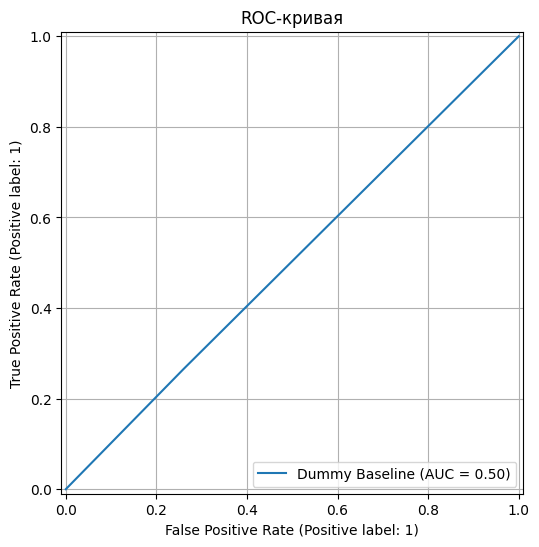

In [359]:
# Простейшая модель 
baseline = DummyClassifier(
    strategy="stratified", 
    random_state=RANDOM_STATE)  # модель генерирует случайные предсказания, соблюдая пропорции классов обучающей выборки

#Обучение
baseline.fit(X_train, y_train)

# Предсказания модели
y_test_pred_baseline = baseline.predict(X_test)
y_test_proba_baseline= baseline.predict_proba(X_test)[:, 1]
print_metrics(y_test, y_test_pred_baseline, y_test_proba_baseline, "Dummy Baseline")

results.append(evaluate_on_test(baseline, X_test, y_test, "Dummy(strarified)"))
best_models["Dummy(stratified)"] = baseline


In [391]:
# Логистическая регрессия
# Создаем пайплайн с логистической регрессией
pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "log_reg",
            LogisticRegression(
                penalty="l2",  # штраф; используем l2, чтобы избежать переобучения
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [392]:
param_grid = {
    'log_reg__C': [0.01, 0.1, 1, 10, 100]  # пробуем разную силу регуляризации
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",  # выбираем метрику, которую хотим максимизировать
    cv=5,               # количество фолдов для кросс-валидации
    n_jobs=-1,          # использовать все ядра процессора
    verbose=1           # чтобы видеть процесс обучения
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший ROC-AUC (по CV):", grid_search.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Лучшие параметры: {'log_reg__C': 100}
Лучший ROC-AUC (по CV): 0.8041495300132466


c:\Users\miphi\classroomAIE\aie-course\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy : 0.8119444444444445
F1-score : 0.5606748864373783
ROC-AUC  : 0.7976938789744817


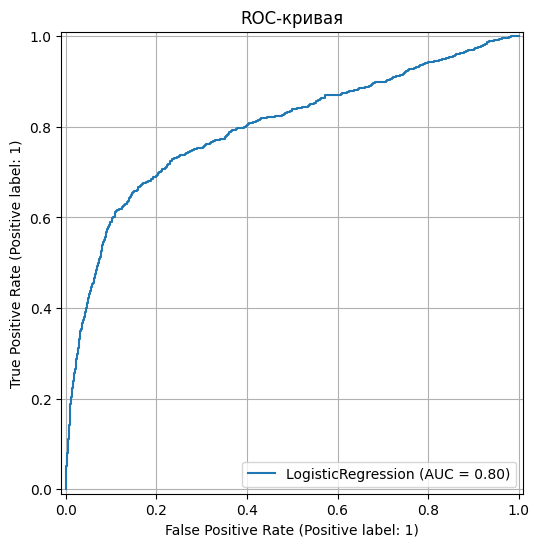

In [362]:
log_reg = grid_search.best_estimator_
y_test_pred_LR = log_reg.predict(X_test)
y_test_proba_LR = log_reg.predict_proba(X_test)[:, 1]
print_metrics(y_test, y_test_pred_LR, y_test_proba_LR, "LogisticRegression")

In [363]:
results.append(evaluate_on_test(log_reg, X_test, y_test, "LogReg"))
best_models["LogReg"] = log_reg
search_summaries["LogReg"] = {
    "best_params": grid_search.best_params_,
    "best_cv_roc_auc": float(grid_search.best_score_),
}


# Decision Forest #

Accuracy : 0.8083333333333333
F1-score : 0.6379853095487933
ROC-AUC  : 0.7552147789435926


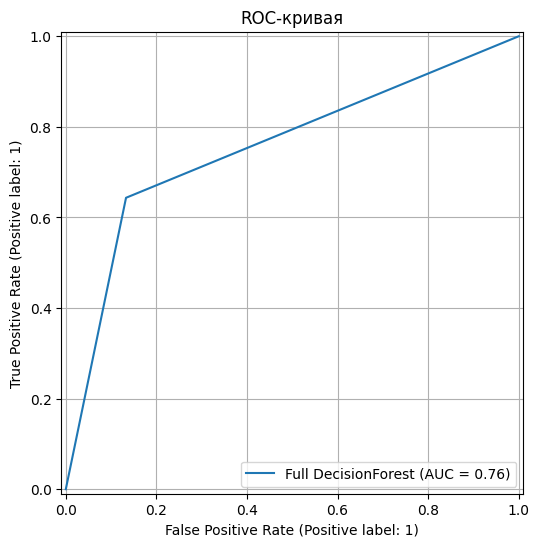

In [364]:
# Обучаем “полное” дерево (без явных ограничений сложности).
# Важно: у DecisionTreeClassifier по умолчанию max_depth=None → дерево растёт, пока может улучшать критерий.
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)

# Сравним качество на train и test – это базовый способ “поймать” переобучение.
y_pred_test = tree_full.predict(X_test)
y_pred_proba_test = tree_full.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_test, y_pred_proba_test, "Full DecisionForest")

In [365]:
m = DecisionTreeClassifier(random_state=RANDOM_STATE)

param_grid_2 = {
    'max_depth': list(range(1, 21)),  # пробуем разную силу регуляризации
    'min_samples_leaf': list(range(1, 21))
}

grid_search_2 = GridSearchCV(
    estimator=m,
    param_grid=param_grid_2,
    scoring= ["accuracy", "roc_auc", "f1"],  # выбираем метрики, которую хотим максимизировать
    refit = "roc_auc",
    cv=5,               # количество фолдов для кросс-валидации
    n_jobs=-1,          # использовать все ядра процессора
    verbose=1           # чтобы видеть процесс обучения
)

grid_search_2.fit(X_train, y_train)

print("Лучшие параметры:", grid_search_2.best_params_)
print("Лучший ROC:", grid_search_2.best_score_)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
Лучшие параметры: {'max_depth': 12, 'min_samples_leaf': 19}
Лучший ROC: 0.8359969631991546


Accuracy : 0.8119444444444445
F1-score : 0.5606748864373783
ROC-AUC  : 0.7976938789744817


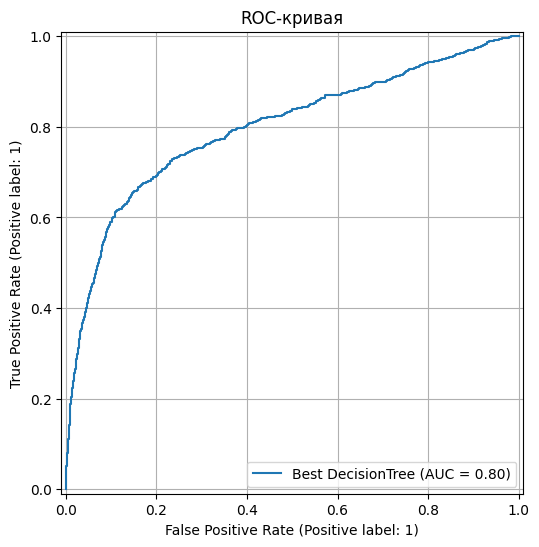

In [366]:
DecTree = grid_search.best_estimator_
print_metrics(y_test, DecTree.predict(X_test), DecTree.predict_proba(X_test)[:, 1], "Best DecisionTree")

In [367]:
results.append(evaluate_on_test(DecTree, X_test, y_test, "DecTree"))
best_models["DecTree"] = DecTree
search_summaries["DecTree"] = {
    "best_params": grid_search_2.best_params_,
    "best_cv_roc_auc": float(grid_search_2.best_score_),
}

### Вывод ###
* Полное дерево переобучается (модель заучивает каждый тестовый пример, подстраивается под шум вместо того, чтобы обобщать и искать закономерности), что заметно влияет на качество
* Контролируя max_depth и min_samples_leaf можно добиться значительно лучшего результата

# Random Forest #

RandomForest oob_score_ = 0.8941
Accuracy : 0.8922222222222222
F1-score : 0.7601977750309024
ROC-AUC  : 0.9287328490718322


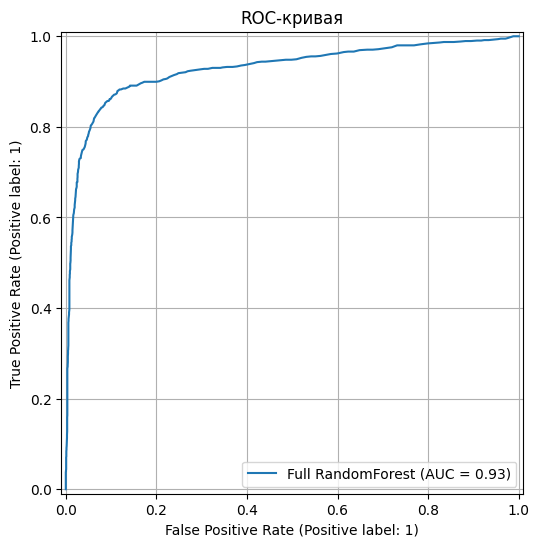

In [368]:
# 3) Random Forest
# Это bagging + дополнительная случайность по признакам на каждом разбиении.
# Смысл: уменьшить корреляцию между деревьями → усилить ансамбль.
#
# Обратите внимание на параметры:
# - n_estimators: сколько деревьев в лесу
# - max_features: сколько признаков пробовать на split (источник “feature randomness”)

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    oob_score=True,
    n_jobs=-1,
    # max_features="sqrt"  # по умолчанию для классификации обычно sqrt(n_features)
)
rf.fit(X_train, y_train)

print(f"RandomForest oob_score_ = {rf.oob_score_:.4f}")
print_metrics(y_test, rf.predict(X_test), rf.predict_proba(X_test)[:, 1], "Full RandomForest")

In [369]:
param_grid_3 = {
    'n_estimators': list(range(100, 601, 100))
}

grid_search_3 = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_3,
    scoring= ["accuracy", "roc_auc", "f1"],  # выбираем метрики, которую хотим максимизировать
    refit = "roc_auc",
    cv=5,               # количество фолдов для кросс-валидации
    n_jobs=-1,          # использовать все ядра процессора
    verbose=1           # чтобы видеть процесс обучения
)

grid_search_3.fit(X_train, y_train)

print("Лучшие параметры:", grid_search_3.best_params_)
print("Лучший ROC:", grid_search_3.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Лучшие параметры: {'n_estimators': 300}
Лучший ROC: 0.9291275468742685


RandomForest oob_score_ = 0.8924
Accuracy : 0.8919444444444444
F1-score : 0.7600246761258482
ROC-AUC  : 0.9286862164828267


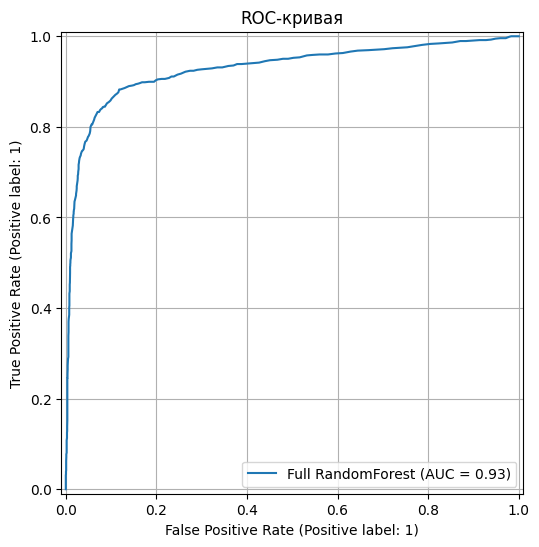

In [370]:
rfb = grid_search_3.best_estimator_
print(f"RandomForest oob_score_ = {rfb.oob_score_:.4f}")
print_metrics(y_test, rfb.predict(X_test), rfb.predict_proba(X_test)[:, 1], "Full RandomForest")

In [371]:
results.append(evaluate_on_test(rfb, X_test, y_test, "RandFor"))
best_models["RandFor"] = rfb
search_summaries["RandFor"] = {
    "best_params": grid_search_3.best_params_,
    "best_cv_roc_auc": float(grid_search_3.best_score_),
}

### Вывод ###
* RandomForest показывает лучшее результаты по сравнению с Decision tree

# Gradient Boosting #

In [372]:
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)

param_grid_4 = {
    'max_depth': list(range(10, 21, 1))
}

grid_search_4 = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_4,
    scoring= ["accuracy", "roc_auc", "f1"],  # выбираем метрики, которую хотим максимизировать
    refit = "roc_auc",
    cv=5,               # количество фолдов для кросс-валидации
    n_jobs=-1,          # использовать все ядра процессора
    verbose=1           # чтобы видеть процесс обучения
)

grid_search_4.fit(X_train, y_train)

print("Лучшие параметры:", grid_search_4.best_params_)
print("Лучший ROC:", grid_search_4.best_score_)

Fitting 5 folds for each of 11 candidates, totalling 55 fits
Лучшие параметры: {'max_depth': 20}
Лучший ROC: 0.9285796826836459


Accuracy : 0.8919444444444444
F1-score : 0.7600246761258482
ROC-AUC  : 0.9286862164828267


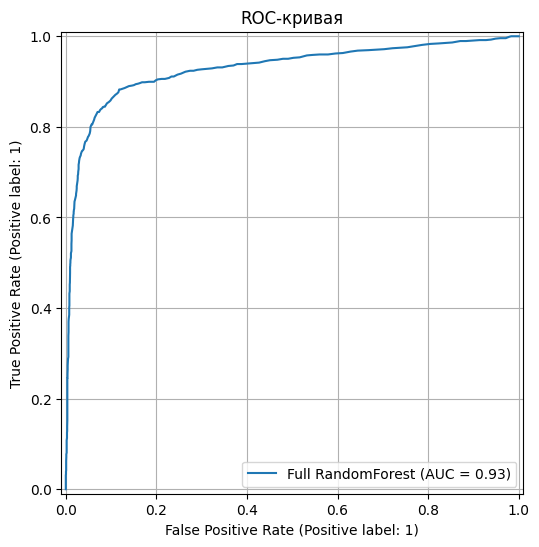

In [373]:
gb = grid_search_4.best_estimator_
print_metrics(y_test, rfb.predict(X_test), rfb.predict_proba(X_test)[:, 1], "Full RandomForest")

In [374]:
results.append(evaluate_on_test(gb, X_test, y_test, "GradBoost"))
best_models["GradBoost"] = gb
search_summaries["GradBoost"] = {
    "best_params": grid_search_4.best_params_,
    "best_cv_roc_auc": float(grid_search_4.best_score_),
}

In [375]:
df = pd.DataFrame(results)

# сортировка: roc_auc (если есть) иначе accuracy
df_sorted = df.copy()
df_sorted["roc_auc_sort"] = df_sorted["roc_auc"].fillna(-1.0)
df_sorted = df_sorted.sort_values(["roc_auc_sort", "accuracy"], ascending=False).drop(columns=["roc_auc_sort"])

df_sorted

,accuracy,f1,roc_auc,model
3,0.891944,0.760025,0.928686,RandFor
4,0.892778,0.761434,0.927426,GradBoost
1,0.811944,0.560675,0.797694,LogReg
2,0.811944,0.560675,0.797694,DecTree
0,0.615278,0.266031,0.502672,Dummy(strarified)


In [376]:
# Выбор “лучшей” модели по таблице результатов.

# Важно: мы НЕ переобучаем и не меняем модель по тесту.
# Мы только выбираем, какую модель будем диагностировать и сохранять.

best_row = df_sorted.iloc[0]
best_label = best_row["model"]
best_model = best_models[best_label]

best_label, best_row.to_dict()

('RandFor',
 {'accuracy': 0.8919444444444444,
  'f1': 0.7600246761258482,
  'roc_auc': 0.9286862164828267,
  'model': 'RandFor'})

In [377]:
# Сохранение артефактов эксперимента в artifacts/.

# После выполнения этой ячейки можно открыть папку artifacts/ и увидеть:
# - metrics_test.json (итоговые метрики)
# - search_summaries.json (лучшие параметры подбора)

metrics_path = ARTIFACTS_DIR / "metrics_test.json"
search_path = ARTIFACTS_DIR / "search_summaries.json"

save_json({"results": df_sorted.to_dict(orient="records")}, metrics_path)
save_json(search_summaries, search_path)

print("Saved:", metrics_path)
print("Saved:", search_path)

Saved: artifacts\metrics_test.json
Saved: artifacts\search_summaries.json


In [378]:
# Сохранение лучшей модели и метаданных.

# - best_model.joblib: сериализованная модель
# - best_model_meta.json: “паспорт” результата (какая модель, какие метрики, какие параметры)

model_path = ARTIFACTS_DIR / "best_model.joblib"
joblib.dump(best_model, model_path)

meta = {
    "best_model_label": best_label,
    "test_metrics": best_row.to_dict(),
    "search_summary": search_summaries.get(best_label, None),
    "random_state": RANDOM_STATE,
}
save_json(meta, ARTIFACTS_DIR / "best_model_meta.json")

print("Saved:", model_path)
print("Saved:", ARTIFACTS_DIR / "best_model_meta.json")

Saved: artifacts\best_model.joblib
Saved: artifacts\best_model_meta.json


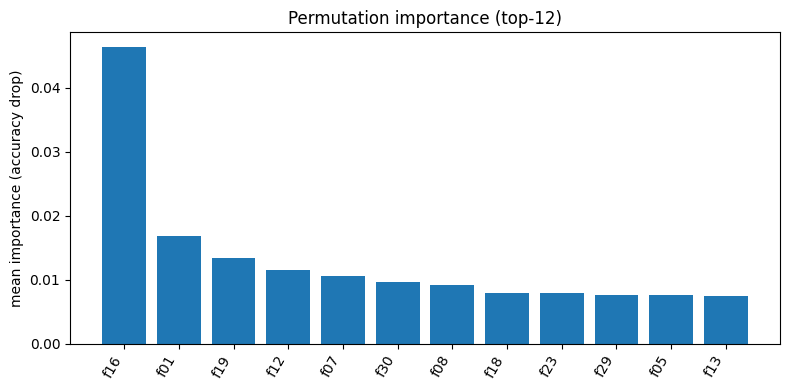

In [379]:
# Permutation importance: по очереди перемешиваем один признак и смотрим, насколько падает качество.
# Чем сильнее падение – тем более “важен” признак для данной модели и данного набора данных.
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

importances = perm.importances_mean
# Сортируем признаки по важности (убывание) и возьмём top-12 для наглядного графика.
idx = np.argsort(importances)[::-1][:12]

feature_names = db.columns.tolist()[1:-1]
plt.figure(figsize=(8, 4))
plt.bar(range(len(idx)), importances[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx], rotation=60, ha="right")
plt.ylabel("mean importance (accuracy drop)")
plt.title("Permutation importance (top-12)")
plt.tight_layout()
plt.show()

### Про признаки ###
* Больше всего влияют следующие признаки: f16, f01, f19, f12, f07
* Похожи ли это на ожидания по данным тяжело сказать

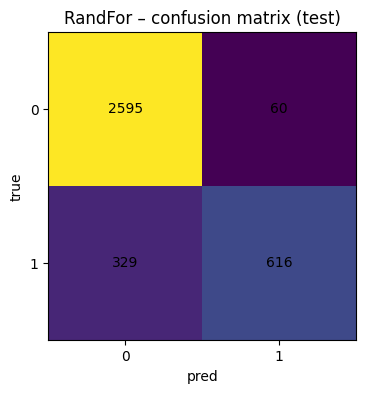

In [393]:
plot_confusion(y_test, best_model.predict(X_test), title=f"{best_label} – confusion matrix (test)")

### Модель лучше предсказывает класс 0
Для класса 0: 2595 правильно, 60 ошибок

Accuracy для класса 0: 2595/2655 = 97.7%

Модель очень уверенно определяет "не-целевой" класс

### Проблемы с классом 1
Для класса 1: 616 правильно, 329 ошибок

Accuracy для класса 1: 616/945 = 65.2%

Каждый третий объект класса 1 классифицируется неправильно

In [395]:
# Сравнение устойчивости при разных random_state
# Мы многократно переобучаем каждую модель с разными seed и собираем метрики.
# Так видно, у какой модели variance больше (шире распределение качества).

seeds = list(range(5, 11))

acc_tree = []
acc_bag = []
acc_rf = []

for s in seeds:
    t = DecisionTreeClassifier(max_depth = 12, min_samples_leaf = 19, random_state = s)
    t.fit(X_train, y_train)
    acc_tree.append(accuracy_score(y_test, t.predict(X_test)))

    r = RandomForestClassifier(n_estimators = 300, random_state = s)
    r.fit(X_train, y_train)
    acc_rf.append(accuracy_score(y_test, r.predict(X_test)))

print(f"DecisionTree: mean={np.mean(acc_tree):.4f}, std={np.std(acc_tree):.4f}")
print(f"RandForest:   mean={np.mean(acc_rf):.4f}, std={np.std(acc_rf):.4f}")

DecisionTree: mean=0.8328, std=0.0004
RandForest:   mean=0.8933, std=0.0013


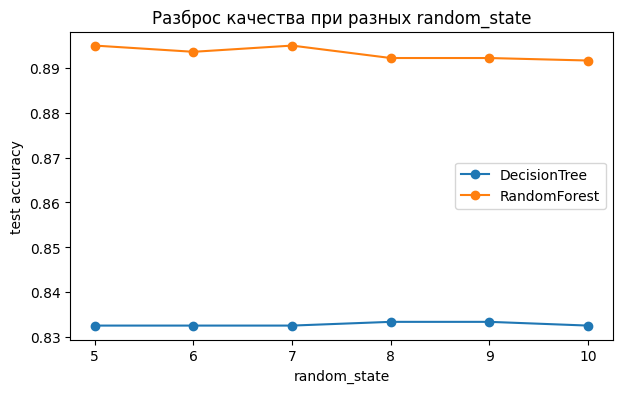

In [396]:
# Визуализация распределений метрик
# Здесь обычно удобно смотреть boxplot/violin: медиана и разброс.
# Чем уже “ящик”, тем стабильнее модель по отношению к случайности.

plt.figure(figsize=(7, 4))
plt.plot(seeds, acc_tree, marker="o", label="DecisionTree")
plt.plot(seeds, acc_rf, marker="o", label="RandomForest")
plt.xlabel("random_state")
plt.ylabel("test accuracy")
plt.title("Разброс качества при разных random_state")
plt.legend()
plt.show()

# Вывод #
* Деревья легко интерпретировать, так как видны правила принятия решений
* Полные деревья часто переобучаются (запоминают каждый тренировочный пример)
* Нужен контроль параметров (max_depth, min_samples_leaf, etc.)
* Ансамбли часто показывают лучший результат, так как каждая модель совершает независимые ошибки (при правильном подходе), тем самым закрывая проблемы другой
* Ансамбли более устойчивы к начальным условиям
* Разнообразие в ансамбли достигается через разные тренировочные данные, разные признаки и даже разные алгоритмы
* Нет единого лучшего алгоритма для всех задач, RF требует мало настройки, так хорошо показывает себя изначально, а GradientBoosing мощнее, но требует больше настроек и ресурсов
* Train/Test split (или CV) ДО любой обработки - необходимая вещь, ведь так можно избежать утечки данных 
* K-fold CV дает более стабильную оценку качества
* Метрики должны соответствовать задаче, например, accuracy обманчив при дисбалансе классов (DummyClasifier с самого начала показывает неплохие результаты, особенно при стратегии most frequent). Для небалансированных датасетов хорошо подойдёт f1

